In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%config InlineBackend.figure_format = 'retina'

In [2]:
# TIME BETWEEN MEASUREMENTS
ta = 0.04 # 40 ms

# LINE PLOTS CONSTANTS
# desired line
M = -1.0
B = 1.0
Pi_x_line = 1.0
Pi_y_line = 0.0
Pf_x_line = 0.0
Pf_y_line = 1.0

kn_values = [0.2, 0.7, 1.2, 5] # values of kn
n_min_line = [54, 28, 154, 71] # first trajectory point in the data
n_max_line = [-7, -1, -55, -1] # last trajectory point in the data
n_pos_line = [0, 182, 180, 178]

# ARC PLOTS CONSTANTS
Pi_x_arc = 0.5
Pi_y_arc = 0.0
Pc_x_arc = 0.5
Pc_y_arc = 0.5
R = 0.5

k_arc = [0.2, 0.7, 1.2, 5] # values of k
n_min_arc = [45, 27, 42, 34] # first trajectory point in the data
n_max_arc = [-1, -1, -1, -1] # last trajectory point in the data
n_pos_arc = [0, 346, 359, 377]

# PRETTY COLORS
plot_colors = ['mediumpurple', 'xkcd:dodger blue', 'yellowgreen', 'orange', 'xkcd:dull red'] # add more colors if more data

# PATHS
im_dir = Path('../Imagens')
im_dir.mkdir(parents = True, exist_ok = True)
data_dir = Path('Dados ks')

# Load data

In [3]:
# lines
xs_line = {}
ys_line = {}
thetas_line = {}

for i in range(1, 5): # modify range if more/less files
    data_line = np.loadtxt(data_dir / f'Line_kn_{kn_values[i]}.log') # t, v, omega, x, y, theta
    t = data_line[:,0]
    v = data_line[:,1]
    w = data_line[:,2]
    x = data_line[:,3]
    y = data_line[:,4]
    theta = data_line[:,5]

    xs_line[i] = x
    ys_line[i] = y
    thetas_line[i] = theta       
    # print(i, len(x) - n_min_line[i - 1] + n_max_line[i - 1])
    

# arcs
xs_arc = {}
ys_arc = {}

for i in range(1, 5): # modify range if more/less files
    data_arc = np.loadtxt(data_dir / f'arc{i}.log')
    # x and y were accidentally stored as angles converted from rad to degree
    x = (A2 + data_arc[:,1] * np.pi / 180.0) * np.cos(data_arc[:,0] * np.pi / 180.0)
    y = (A2 + data_arc[:,1] * np.pi / 180.0) * np.sin(data_arc[:,0] * np.pi / 180.0)
    xs_arc[i] = x
    ys_arc[i] = y
    print(i, len(x) - n_min_arc[i - 1] + n_max_arc[i - 1])

1 226
2 209
3 209
4 208
1 385
2 377
3 372
4 392


# Trajectory and error plots

## Lines

k = 0.2, RMSE = 0.069
k = 0.7, RMSE = 0.032
k = 1.2, RMSE = 0.024
k = 5, RMSE = 0.014


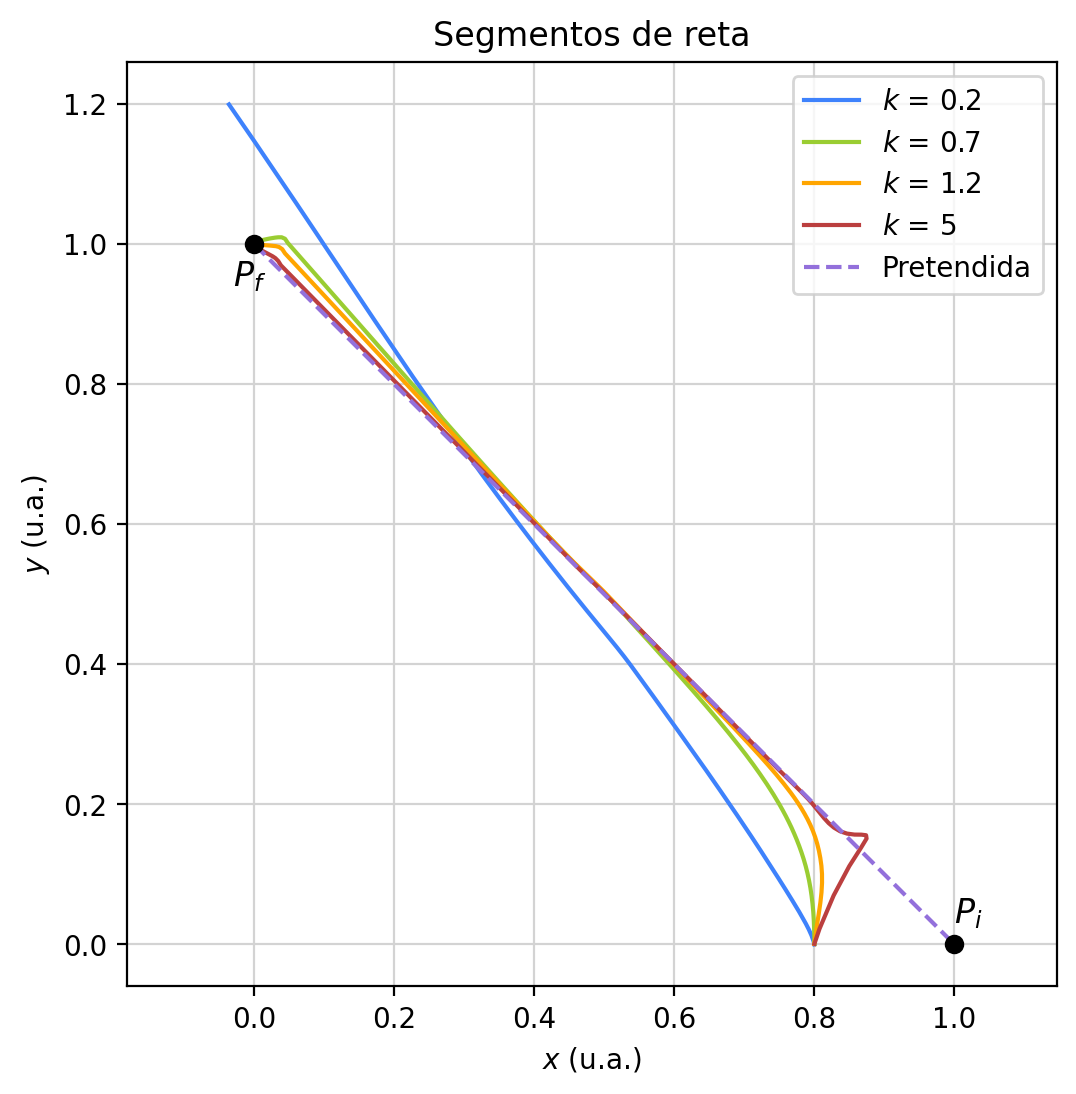

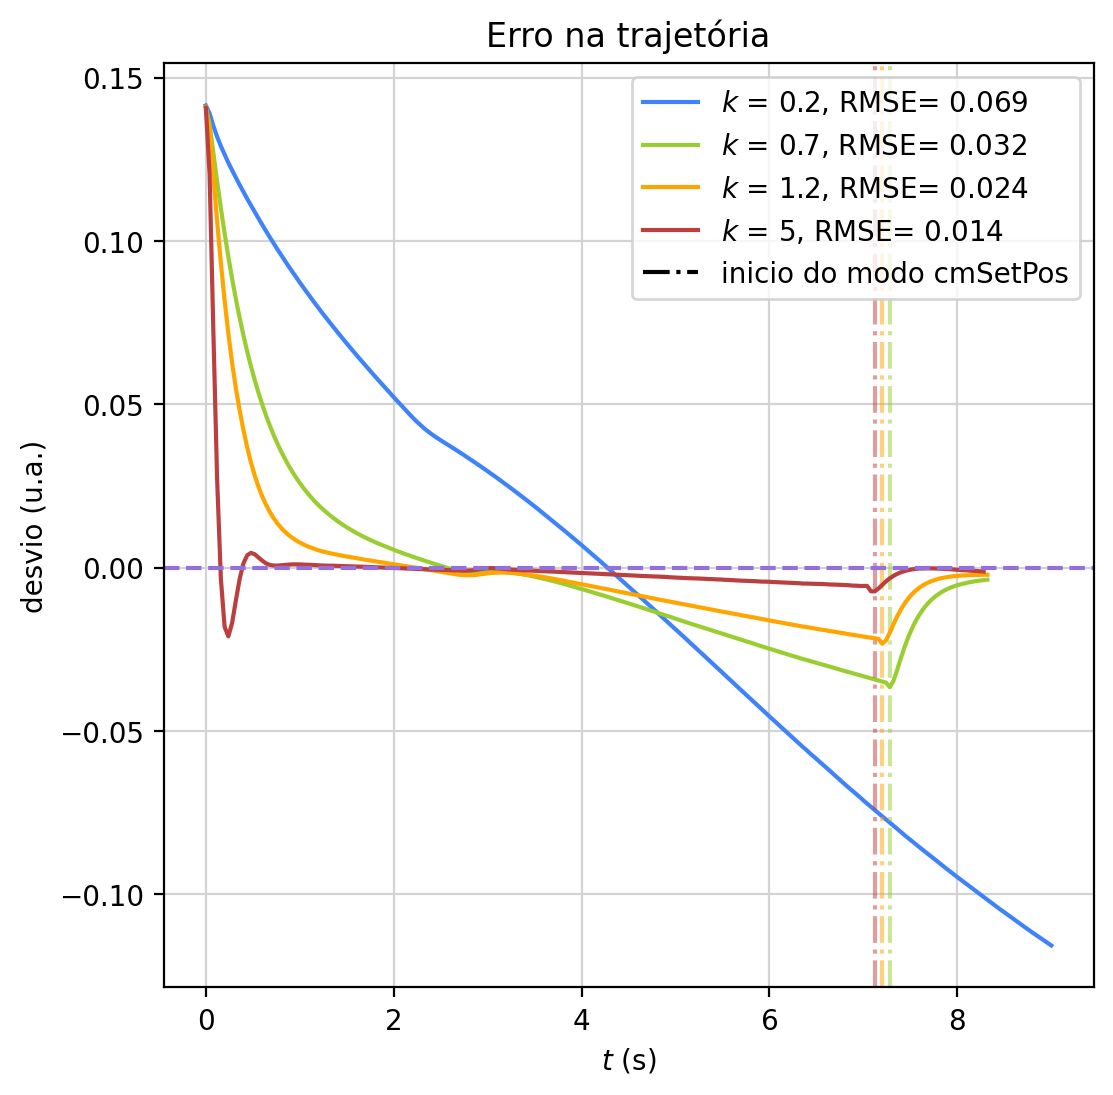

In [4]:
# desired line
xd_line = np.linspace(0.0, 1.0, 100)
yd_line = M * xd_line + B

# rmse
rmse_line = np.zeros(5)

# trajectory plot
fig_traj, ax_traj = plt.subplots(figsize=(6,6))
ax_traj.axis('equal')
ax_traj.set_title('Segmentos de reta')
ax_traj.grid(color = 'lightgray')
ax_traj.set_xlabel(r'$x$ (u.a.)')
ax_traj.set_ylabel(r'$y$ (u.a.)')

# error plot
fig_error, ax_error = plt.subplots(figsize=(6,6))
ax_error.set_title('Erro na trajetória')
ax_error.grid(color = 'lightgray')
ax_error.set_xlabel(r'$t$ (s)')
ax_error.set_ylabel('desvio (u.a.)')

for i in range(1, 3):
    xi = xs_line[i]
    yi = ys_line[i]

    # apply range
    xi = xi[n_min_line[i - 1]:n_max_line[i - 1]]
    yi = yi[n_min_line[i - 1]:n_max_line[i - 1]]

    N = len(xi)

    # plot trajectory
    ax_traj.plot(xi, yi, label = fr'$k$ = {k_line[i - 1]}', color = plot_colors[i])

    # calculate error
    # u_hat_if
    u_if_x = Pf_x_line - Pi_x_line
    u_if_y = Pf_y_line - Pi_y_line
    
    norm_u_if = np.sqrt(u_if_x ** 2 + u_if_y ** 2)
    u_hat_if_x = u_if_x / norm_u_if
    u_hat_if_y = u_if_y / norm_u_if

    # u_in
    u_ir_x = xi - Pi_x_line
    u_ir_y = yi - Pi_y_line

    proj = u_hat_if_x * u_ir_x + u_hat_if_y * u_ir_y

    u_in_x = u_hat_if_x * proj
    u_in_y = u_hat_if_y * proj

    # u_rn
    P_n_x = u_in_x + Pi_x_line
    P_n_y = u_in_y + Pi_y_line

    u_rn_x = P_n_x - xi
    u_rn_y = P_n_y - yi

    # error
    # erro = np.sqrt(u_rn_x ** 2 + u_rn_y ** 2)
    erro = - u_hat_if_x * u_rn_x + u_hat_if_y * u_rn_y

    # calculate rmse
    rmse_line[i - 1] = np.sqrt(np.sum(erro ** 2) / len(erro))

    # plot error
    ax_error.plot(np.arange(0, N)*ta, erro, label = fr'$k$ = {k_line[i - 1]}, RMSE= {rmse_line[i - 1]:.3f}', color = plot_colors[i])
    if n_pos_line[i - 1] != 0:
        ax_error.axvline(n_pos_line[i - 1] * ta, linestyle = '-.', color = plot_colors[i], alpha = 0.5)

    print(f'k = {k_line[i - 1]}, RMSE = {rmse_line[i - 1]:.3f}')


ax_traj.plot(xd_line, yd_line, '--', label = 'Pretendida', color = plot_colors[0])
ax_traj.legend(loc = 'upper right')
ax_traj.plot(Pi_x_line, Pi_y_line, 'o', color='black')
ax_traj.text(Pi_x_line, Pi_y_line + 0.03, r'$P_i$', size='large')
ax_traj.plot(Pf_x_line, Pf_y_line, 'o', color='black')
ax_traj.text(Pf_x_line-0.03, Pf_y_line - 0.06, r'$P_f$', size='large')
fig_traj.savefig(im_dir/'traj_line_k.png', dpi = 300, bbox_inches = 'tight')

ax_error.axhline(0, linestyle = '--', color = plot_colors[0])
handles, labels = ax_error.get_legend_handles_labels()
handles.append(Line2D([0], [0], linestyle = '-.', color='black', label = 'cmSetPos'))
labels.append('inicio do modo cmSetPos')
ax_error.legend(handles = handles, labels = labels, loc = 'upper right')
fig_error.savefig(im_dir/'error_line_k.png', dpi = 300, bbox_inches = 'tight')

plt.show()

## Arcs

k = 0.2, RMSE = 0.095
k = 0.7, RMSE = 0.039
k = 1.2, RMSE = 0.028
k = 5, RMSE = 0.014


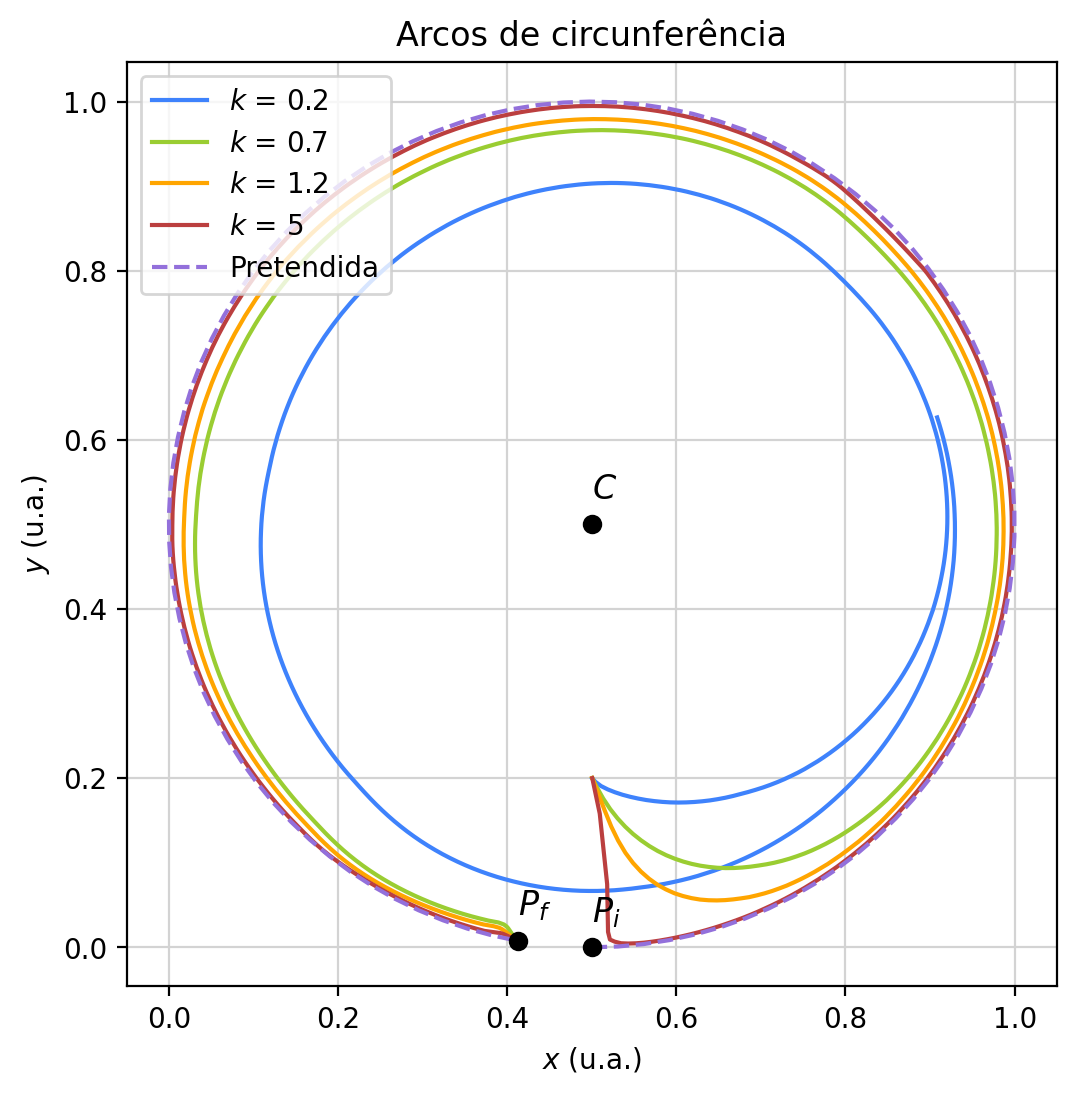

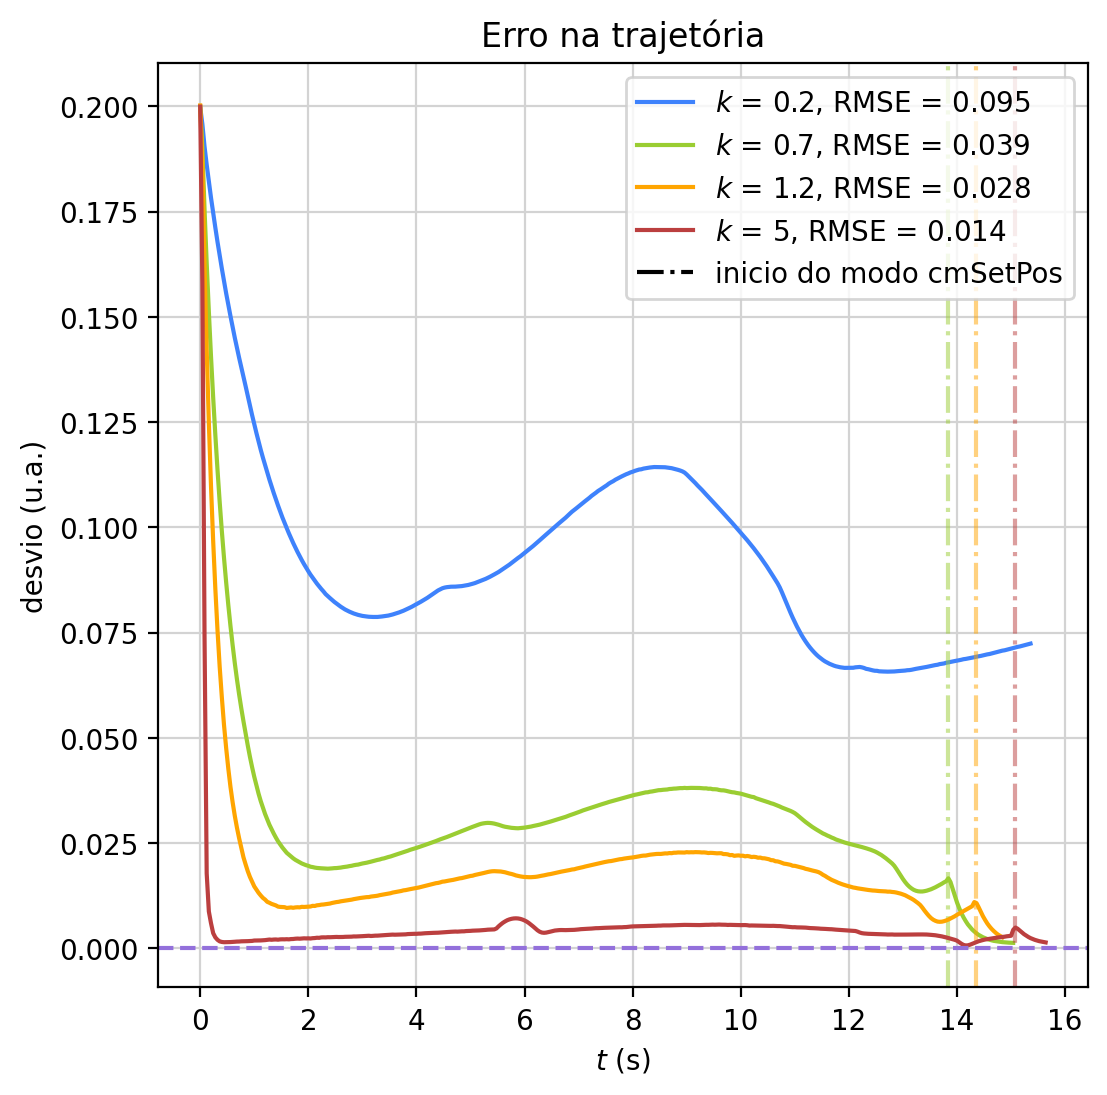

In [5]:
# desired arc
thetad_arc = np.linspace(-np.pi/2, 350*np.pi/180 - np.pi/2, 100)
xd_arc = 0.5 * np.cos(thetad_arc) + 0.5
yd_arc = 0.5 * np.sin(thetad_arc) + 0.5

# rmse
rmse_arc = np.zeros(5)

# trajectory plot
fig_traj, ax_traj = plt.subplots(figsize=(6,6))
ax_traj.axis('equal')
ax_traj.set_title('Arcos de circunferência')
ax_traj.grid(color = 'lightgray')
ax_traj.set_xlabel(r'$x$ (u.a.)')
ax_traj.set_ylabel(r'$y$ (u.a.)')

# error plot
fig_error, ax_error = plt.subplots(figsize=(6,6))
ax_error.set_title("Erro na trajetória")
ax_error.grid(color = 'lightgray')
ax_error.set_xlabel(r'$t$ (s)')
ax_error.set_ylabel('desvio (u.a.)')

for i in range(1, 5):
    xi = xs_arc[i]
    yi = ys_arc[i]

    # apply range
    xi = xi[n_min_arc[i - 1]:n_max_arc[i - 1]]
    yi = yi[n_min_arc[i - 1]:n_max_arc[i - 1]]

    N = len(xi)

    # plot trajectory
    ax_traj.plot(xi, yi, label = fr'$k$ = {k_arc[i - 1]}', color = plot_colors[i])

    # calculate error
    # u_hat_cr
    u_cr_x = xi - Pc_x_arc
    u_cr_y = yi - Pc_y_arc
    
    norm_u_cr = np.sqrt(u_cr_x ** 2 + u_cr_y ** 2)
    u_hat_cr_x = u_cr_x / norm_u_cr
    u_hat_cr_y = u_cr_y / norm_u_cr

    # cálculo do u_rn
    P_n_x = Pc_x_arc + R * u_hat_cr_x
    P_n_y = Pc_y_arc + R * u_hat_cr_y

    u_rn_x = P_n_x - xi
    u_rn_y = P_n_y - yi

    # error
    # erro = np.sqrt(u_rn_x ** 2 + u_rn_y ** 2)
    erro = R - norm_u_cr # normal and radial direction are the same
    if n_pos_arc[i - 1] != 0:
        ax_error.axvline(n_pos_arc[i - 1] * ta, linestyle = '-.', color = plot_colors[i], alpha = 0.5)

    # calculate rmse
    rmse_arc[i - 1] = np.sqrt(np.sum(erro ** 2) / len(erro))

    # plot error
    plt.plot(np.arange(0, N)*ta, erro, label = fr'$k$ = {k_arc[i - 1]}, RMSE = {rmse_arc[i - 1]:.3f}', color = plot_colors[i])

    print(f'k = {k_arc[i - 1]}, RMSE = {rmse_arc[i - 1]:.3f}')


ax_traj.plot(xd_arc, yd_arc, '--', label = 'Pretendida', color = plot_colors[0])
ax_traj.legend(loc = 'upper left')
ax_traj.plot(Pc_x_arc, Pc_y_arc, 'o', color = 'black')
ax_traj.text(Pc_x_arc, Pc_y_arc + 0.03, r'$C$', size='large')
ax_traj.plot(Pi_x_arc, Pi_y_arc, 'o', color = 'black')
ax_traj.text(Pi_x_arc, Pi_y_arc + 0.03, r'$P_i$', size = 'large')
ax_traj.plot(xd_arc[-1], yd_arc[-1], 'o', color='black')
ax_traj.text(xd_arc[-1], yd_arc[-1] + 0.03, r'$P_f$', size='large')
fig_traj.savefig(im_dir/'traj_arc_k.png', dpi = 300, bbox_inches = 'tight')

ax_error.axhline(0, linestyle = '--', color = plot_colors[0])
handles, labels = ax_error.get_legend_handles_labels()
handles.append(Line2D([0], [0], linestyle = '-.', color = 'black', label = 'cmSetPos'))
labels.append('inicio do modo cmSetPos')
ax_error.legend(handles = handles, labels = labels,loc = 'upper right')
fig_error.savefig(im_dir/'error_arc_k.png', dpi = 300, bbox_inches = 'tight')

plt.show()